# Investigating metadata pulled from SRA + NCBI

This is paired-end data that mention "artic" primers in the experiment description from SARS-COV-2. SRA data includes # of spots, artic primer versions, and SRA numbers. NCBI virus provides all other metadata.

In [8]:
# Importing libraries

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from tabulate import tabulate

In [2]:
# Loading data
metadata = pd.read_csv("/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/metadata/ncbi_virus_meta.csv")

## EDA/Summary statistics

In [12]:
summary = metadata.groupby("Pangolin").agg(N=("Pangolin", "count"),
                                            Spots_q25=("Spots", lambda x: x.quantile(0.25)),
                                            Spots_q50=("Spots", lambda x: x.quantile(0.5)),
                                            Spots_q75=("Spots", lambda x: x.quantile(0.75)),
                                            Spots_min=("Spots", "min"),
                                            Spots_max=("Spots", "max"))
summary

,N,Spots_q25,Spots_q50,Spots_q75,Spots_min,Spots_max
Pangolin,,,,,,
B.1.1,496,336187.75,564222.5,1491589.00,7392,11986390
B.1.1.529,48,149040.75,385762.5,2253863.75,14470,8733302
B.1.1.7,14584,336543.50,957067.0,4110249.25,0,31342715
B.1.351,153,145275.00,1509558.0,6359407.00,4181,11941860
B.1.617.2,2465,227371.00,509876.0,1374789.00,6210,17748331
P.1,1797,341257.00,829323.0,1220464.00,7254,13157455


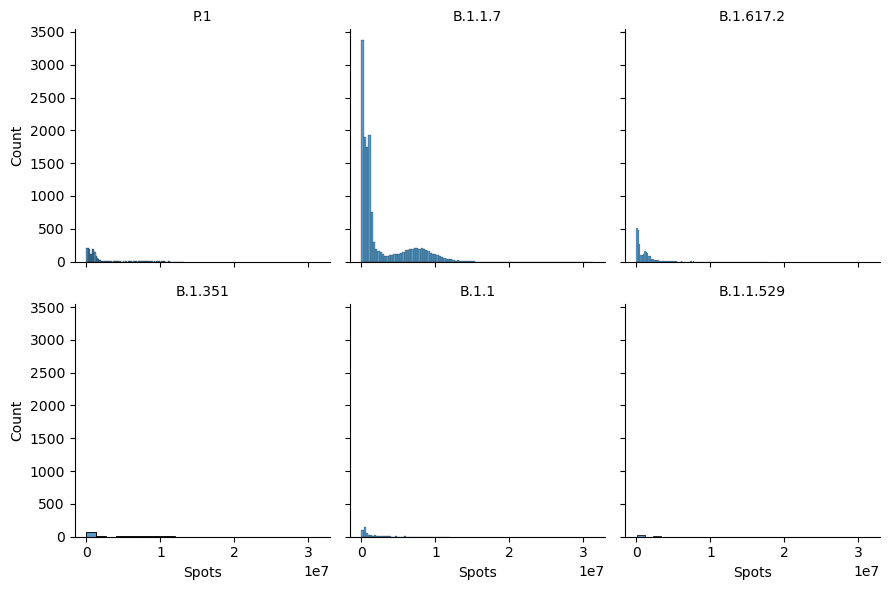

In [14]:
grid = sns.FacetGrid(data = metadata, col = "Pangolin", col_wrap = 3)
grid.map(sns.histplot, "Spots")
grid.set_axis_labels("Spots", "Count")
grid.set_titles("{col_name}")
plt.show()

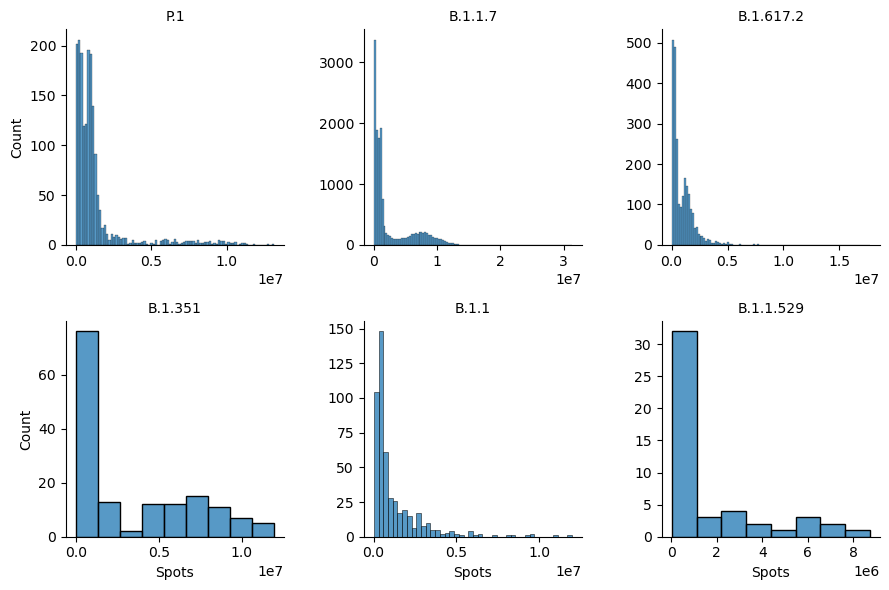

In [15]:
grid = sns.FacetGrid(data = metadata, col = "Pangolin", col_wrap = 3, sharey=False, sharex=False)
grid.map(sns.histplot, "Spots")
grid.set_axis_labels("Spots", "Count")
grid.set_titles("{col_name}")
plt.show()

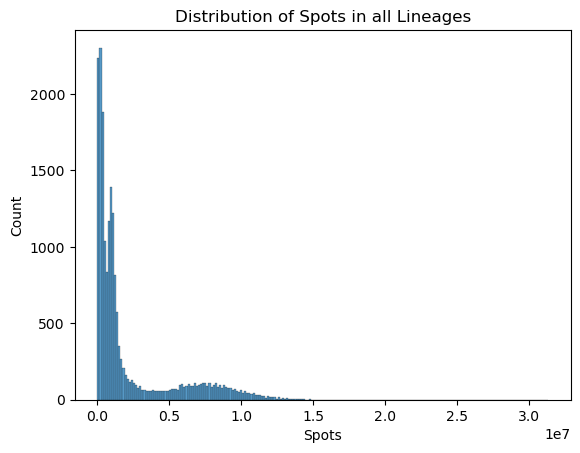

In [18]:
sns.histplot(data = metadata, x= "Spots")
#plt.set_axis_labels("Spots", "Count")
plt.title("Distribution of Spots in all Lineages")
plt.show()

In [32]:
test_method = metadata[metadata["Spots"]<=8733302].groupby("Pangolin", as_index=True).apply(lambda x: x.nlargest(15, 'Spots')).reset_index()

#test_method["Pangolin"]
test_method

test_summary = test_method.groupby("Pangolin").agg(N=("Pangolin", "count"),
                                            Spots_q25=("Spots", lambda x: x.quantile(0.25)),
                                            Spots_q50=("Spots", lambda x: x.quantile(0.5)),
                                            Spots_q75=("Spots", lambda x: x.quantile(0.75)),
                                            Spots_min=("Spots", "min"),
                                            Spots_max=("Spots", "max"))
test_summary

,N,Spots_q25,Spots_q50,Spots_q75,Spots_min,Spots_max
Pangolin,,,,,,
B.1.1,15,5094827.5,5888816.0,6477020.0,4634634,8529522
B.1.1.529,15,2537201.0,4170088.0,5926580.0,1240987,8733302
B.1.1.7,15,8719443.0,8722761.0,8727740.5,8712325,8731912
B.1.351,15,7144657.5,7664505.0,7974909.5,6885801,8607983
B.1.617.2,15,6332864.0,6975054.0,7568769.0,5810824,8710968
P.1,15,8116549.5,8220325.0,8524606.0,7965925,8688900


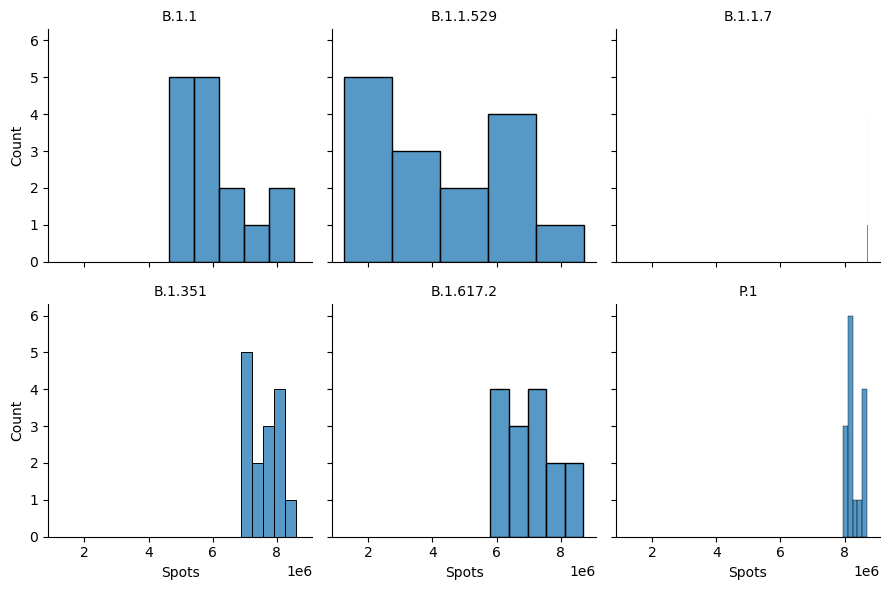

In [34]:
grid = sns.FacetGrid(data = test_method, col = "Pangolin", col_wrap = 3, sharey=True, sharex=True)
grid.map(sns.histplot, "Spots")
grid.set_axis_labels("Spots", "Count")
grid.set_titles("{col_name}")
plt.show()